In [ ]:
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
ds = load_dataset("CARROT-LLM-Routing/SPROUT-o3mini")
ds_test = load_dataset("CARROT-LLM-Routing/SPROUT-o3mini", split = 'test')
ds_train = load_dataset("CARROT-LLM-Routing/SPROUT-o3mini", split = 'train')
COSTS = {'openai-o3-mini': [1.1, 4.40], 'aws-claude-3-5-sonnet-v1': [3, 15], 'aws-titan-text-premier-v1': [0.5, 1.5],
            'openai-gpt-4o': [2.5, 10], 'openai-gpt-4o-mini': [0.15, 0.6],
            'wxai-granite-3-2b-instruct-8k-max-tokens': [0.1, 0.1],
            'wxai-granite-3-8b-instruct-8k-max-tokens': [0.2, 0.2],
            'wxai-llama-3-1-70b-instruct': [0.9, 0.9], 'wxai-llama-3-1-8b-instruct': [0.2, 0.2],
            'wxai-llama-3-2-1b-instruct': [0.06, 0.06], 'wxai-llama-3-2-3b-instruct': [0.06, 0.06],
            'wxai-llama-3-3-70b-instruct': [0.9, 0.9], 'wxai-mixtral-8x7b-instruct-v01': [0.6, 0.6],
            'wxai-llama-3-405b-instruct': [3.5, 3.5]
        }
## CORRECTLY FORMAT DATA
all_models = ds_test.to_pandas().columns.tolist()[6:]
print(COSTS.keys())
print(all_models)
test_inputs = ds_test['prompt']
EXP = 'cost'
def get_labels(split, models, mode):
    labels = []
    labelsin = []
    if mode == 'cost':
        for m in models:
            labels.append([sample['num_output_tokens']*COSTS[m][0]/1000000 for sample in split[m]])
            labelsin.append([sample['num_output_tokens']*COSTS[m][1]/1000000 for sample in split[m]])
        return np.array(labels).T, np.array(labelsin).T
    else:
        for m in models:
            labels.append([sample['score'] for sample in split[m]])
        return np.array(labels).T
if EXP == 'cost':
    train_labels = get_labels(ds_train, all_models, 'cost')
cost_mean_output, cost_mean_input = np.mean(train_labels[0], axis=0), np.mean(train_labels[1], axis=0)
avg_costs = cost_mean_output+cost_mean_input

dict_keys(['openai-o3-mini', 'aws-claude-3-5-sonnet-v1', 'aws-titan-text-premier-v1', 'openai-gpt-4o', 'openai-gpt-4o-mini', 'wxai-granite-3-2b-instruct-8k-max-tokens', 'wxai-granite-3-8b-instruct-8k-max-tokens', 'wxai-llama-3-1-70b-instruct', 'wxai-llama-3-1-8b-instruct', 'wxai-llama-3-2-1b-instruct', 'wxai-llama-3-2-3b-instruct', 'wxai-llama-3-3-70b-instruct', 'wxai-mixtral-8x7b-instruct-v01', 'wxai-llama-3-405b-instruct'])
['openai-o3-mini', 'wxai-llama-3-405b-instruct', 'wxai-llama-3-3-70b-instruct', 'wxai-llama-3-2-3b-instruct', 'wxai-llama-3-2-1b-instruct', 'wxai-llama-3-1-8b-instruct', 'wxai-llama-3-1-70b-instruct', 'aws-titan-text-premier-v1', 'wxai-mixtral-8x7b-instruct-v01', 'aws-claude-3-5-sonnet-v1', 'openai-gpt-4o-mini', 'openai-gpt-4o', 'wxai-granite-3-8b-instruct-8k-max-tokens', 'wxai-granite-3-2b-instruct-8k-max-tokens']


In [2]:
#from transformers import AutoTokenizer, AutoModelForSequenceClassification
#import numpy as np
import torch
from tqdm import tqdm
bench = ''
hf_tok = ""
carr_tok = ""

input_counter = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-70B", token=hf_tok)
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

score_predictor = AutoModelForSequenceClassification.from_pretrained(
    'CARROT-LLM-Routing/Perfo3',
    problem_type="multi_label_classification",
    num_labels=len(COSTS), token = carr_tok
)


# Example queries
prompts = ds_test['prompt']
#prompts = [e['prompt'] for i, e in enumerate(arena) if bench in e['dataset']]
#prompts = ds['test']['prompt'][MMLUids]
#prompts = arena['prompt']
scores = []
input_tokens = []
output_tokens = []
costs = []
for idx, m in enumerate(all_models):
    scores_m = []
    input_tokens_m = []
    output_tokens_m = []
    for entry in ds_test:
    #for entry in arena:
        if bench in entry['dataset']:
            scores_m.append(entry[m]["score"])
            input_tokens_m.append(entry[m]["num_input_tokens"])
            output_tokens_m.append(entry[m]["num_output_tokens"])
    scores.append(scores_m)
    input_tokens.append(input_tokens_m)
    output_tokens.append(output_tokens_m) 
input_tokens = np.array(input_tokens).T
output_tokens = np.array(output_tokens).T
for i, model in enumerate(all_models):
            cost = (input_tokens[:, i] * COSTS[model][0] / 1000000) \
                        + (output_tokens[:, i] * COSTS[model][1] / 1000000)
            costs.append(cost.tolist())
scores = np.array(scores).T
costs = np.array(costs).T
input_counter.pad_token = tokenizer.eos_token

print('predicting score')

device = "cuda" if torch.cuda.is_available() else "cpu"

score_predictor = score_predictor.to(device)

batch_size = 1  # Adjust based on memory limits
p_scores = []
p_logits = []
for i, prompt in tqdm(enumerate(prompts), total = len(prompts)):
    tokenized_text = tokenizer(
           prompt,
            truncation=True,
            is_split_into_words=False,
            return_tensors='pt'
       )
    tokenized_text.to(device)
    with torch.no_grad():
        p_scores.append(1 / (1 + np.exp(-score_predictor(tokenized_text['input_ids']).logits.cpu().numpy())))
        p_logits.append(score_predictor(tokenized_text['input_ids']).logits.cpu().numpy())
        #p_output_tokens.append(output_counter(batch).logits.cpu().numpy())

#p_scores = 1 / (1 + np.exp(-score_predictor.predict(tokenized_text["input_ids"]).logits.cpu().detach().numpy()))
del score_predictor

torch.cuda.empty_cache()

import gc
gc.collect()

print('predicting cost')
output_counter = AutoModelForSequenceClassification.from_pretrained(
    'CARROT-LLM-Routing/costo3',
    problem_type="regression",
    num_labels=len(COSTS), token = carr_tok
)
p_output_tokens = []
output_counter = output_counter.to(device)
for i, prompt in tqdm(enumerate(prompts), total = len(prompts)):
    tokenized_text = tokenizer(
           prompt,
            truncation=True,
            is_split_into_words=False,
            return_tensors='pt'
       )
    tokenized_text.to(device)
    with torch.no_grad():
        #p_scores.append(1 / (1 + np.exp(-score_predictor(tokenized_text).logits.cpu().numpy())))
        p_output_tokens.append(output_counter(tokenized_text['input_ids']).logits.cpu().numpy())
print('counting inputs')
    #print(model_idx.shape)

predicting score


100%|███████████████████████████████████████| 6494/6494 [01:31<00:00, 71.28it/s]


predicting cost


100%|██████████████████████████████████████| 6494/6494 [00:48<00:00, 134.96it/s]

counting inputs


In [3]:
cost_mean_output, cost_mean_input = np.mean(train_labels[0], axis=0), np.mean(train_labels[1], axis=0)
avg_costs = cost_mean_output+cost_mean_input
api_costs = np.array([COSTS[k][1]/1000000 for k in COSTS.keys()])

In [4]:
print('counting inputs')
p_scores = np.concatenate(p_scores, axis = 0)
p_logits = np.concatenate(p_logits, axis=0)
p_output_tokens = np.concatenate(p_output_tokens, axis = 0)
p_input_tokens = [input_counter(prompt, return_tensors="pt")["input_ids"].shape[1] for prompt in prompts]
p_input_tokens = np.array(p_input_tokens).T

p_costs = []
for i, model in enumerate(all_models):
    p_cost = (p_input_tokens * COSTS[model][0] / 1000000) + (p_output_tokens[:, i] * COSTS[model][1] / 1000)
    p_costs.append(p_cost.tolist())
p_costs = np.array(p_costs).T
lamb_range = np.arange(0, 1.001, 0.01)
router_cost = np.zeros(shape = (scores.shape[0], lamb_range.shape[0]))
base_cost = np.zeros(shape = (scores.shape[0], lamb_range.shape[0]))
router_perf = np.zeros_like(router_cost)
base_perf = np.zeros_like(router_cost)
for idx_lam, lam in enumerate(lamb_range):
    model_idx = ((1 - lam) * p_scores - lam * p_costs * 100).argmax(axis=1, keepdims=True)
    rbench_idx = ((1 - lam) * p_scores - lam * avg_costs * 100).argmax(axis=1, keepdims=True)
    router_perf[:, idx_lam] = np.take_along_axis(scores, model_idx, axis = 1).reshape((-1))
    router_cost[:, idx_lam] = np.take_along_axis(costs, model_idx, axis = 1).reshape((-1))
    base_perf[:, idx_lam] = np.take_along_axis(scores, rbench_idx, axis = 1).reshape((-1))
    base_cost[:, idx_lam] = np.take_along_axis(costs, rbench_idx, axis = 1).reshape((-1))
    #print(model_idx.shape)

counting inputs


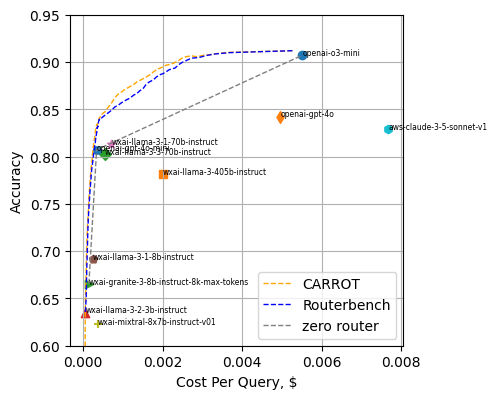

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize = (4.3, 4.3))
markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'x', '+', 'h', 'H', 'd', '>', 'P']
zerorouters = [12, 10, 0]
ax.errorbar(router_cost.mean(axis = 0), router_perf.mean(axis = 0),
        linestyle='--', linewidth=1, alpha = 1, c = 'orange', label = 'CARROT')
ax.errorbar(base_cost.mean(axis = 0), base_perf.mean(axis = 0),
        linestyle='--', linewidth=1, alpha = 1, c = 'blue', label = 'Routerbench')
cost_mean = costs.mean(axis = 0)
scores_mean = scores.mean(axis = 0)
ax.errorbar(cost_mean[zerorouters], scores_mean[zerorouters],
        linestyle='--', linewidth=1, alpha = 1, c = 'grey', label = 'zero router')
for i, txt in enumerate(all_models):
    x, y = cost_mean[i], scores_mean[i]
    ax.scatter([x], [y], marker = markers[i])
    ax.annotate(all_models[i], (x, y), size=5.5)
    #ax.annotate(l, (x, y))
ax.set_xlabel('Cost Per Query, \$')
ax.set_ylabel('Accuracy')
#ax.set_xlim(0, 0.005)
ax.set_ylim(0.60, 0.95)
# ax.plot(cost_router.mean(axis = 0), correctness_router.mean(axis = 0), linestyle='-', linewidth=2, label='router', alpha = 0.3)
ax.legend(loc = 'lower right')
ax.grid(True)
ax.grid(True)
#plt.savefig('SPROUTneurips.pdf', bbox_inches = 'tight', dpi = 400, transparent=False)

In [ ]:
def AUC(cost, perf):
    AUC = np.trapz(perf, cost)/(np.max(cost)-np.min(cost))
    return -AUC
print('CARROT:' +str(AUC(router_cost.mean(axis = 0), router_perf.mean(axis = 0))))
print('Routerbench:' + str(AUC(base_cost.mean(axis = 0), base_perf.mean(axis = 0))))
print('Zero Router:' + str(AUC(cost_mean[zerorouters], scores_mean[zerorouters])))


In [ ]:
benchmarks = {'ragbench': ([], []), 'gpqa': ([], []), 'MuSR': ([], []), 'MMLU-Pro': ([], []), 'MATH': ([], []), 'openhermes': ([], [])}
for idx, entry in enumerate(tqdm(ds['test']['prompt'])):
    for bmrk in benchmarks.keys():
        if bmrk in ds['test']['dataset'][idx]:
            benchmarks[bmrk][0].append(np.mean(np.abs(p_costs[idx]-costs[idx])))
            p_corr = np.where(p_scores[idx] < 0.5, 0, 1)
            corr = np.where(scores[idx] < 0.5, 0, 1)
            benchmarks[bmrk][1].append(np.mean([1 if p_corr[j]==corr[j] else 0 for j in range(len(corr))]))

In [ ]:
for bmrk in benchmarks.keys():
    print(bmrk+' cost MAE:' + str(np.mean(benchmarks[bmrk][0])))
    print(bmrk+' performance acc:' + str(np.mean(benchmarks[bmrk][1])))